# **Team Communication Processing and Analysis in Human-Factors Simulated Environment**

#  **PHASE 1: Dataset Identification and Evaluation!**



## **1. Candidate Datasets Evaluation**

---



We will define selection criteria based on the project's core requirement of processing team communication audio from simulated environments to enable research on coordination, distraction and performance.
Below is the criteria:
- Multi-party team interaction (more than 2 participants)
- Audio/Visual recordings consisting video and audio data.
- Stimulated and collaborative environment
- Support for Human Factors analysis
- Headset vs Array audio data

**Candidate Datasets: AMI Meeting Corpus, LibriCSS, ICSI**

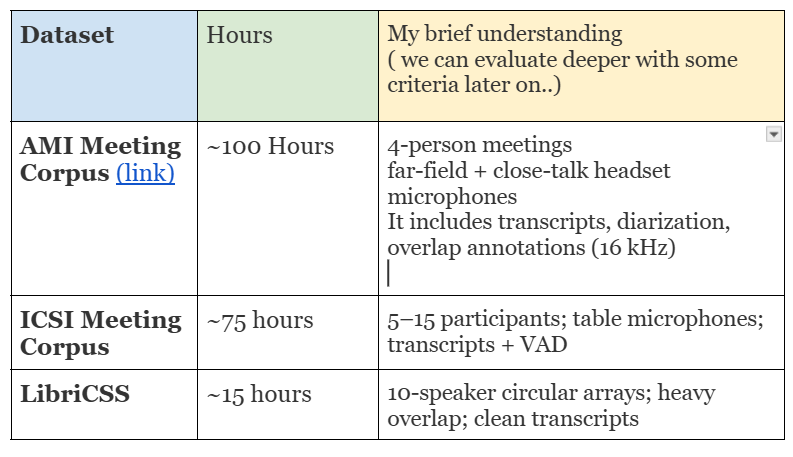

## **2. Selected Resource - AMI MEETING CORPUS**

---




**Meeting Used**: ES2008a  
**Participants**: 4 (Project Manager, Industrial Designer, UI Designer, Marketing Expert)  
**Microphones Used**:
- Mix-Headset (close-talk)
- Array1-01 (far-field)

whY? Because of the hours and the array microphone provides noisy team audiO and the headset mix provides a clean reference signal, it fits the description of the lab's audio samples.

( The dataset was accessed directly from the AMI repo to ensure synchronized microphone channels instead of huggingface which has data of 4-5 secs each, not ideal )

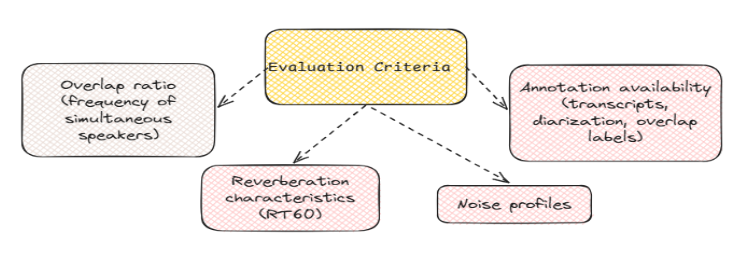


## **3. Technical Exploratory Analysis**

---



## **3.1.1 Download the audio files**

In [1]:
import os
# we can run this cell to download the sample audio files
# dataset link: https://groups.inf.ed.ac.uk/ami/download/
files = {
    "ES2008a.Mix-Headset.wav": "https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2008a/audio/ES2008a.Mix-Headset.wav",
    "ES2008a.Array1-01.wav": "https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/ES2008a/audio/ES2008a.Array1-01.wav"
}
for filename, url in files.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        !wget -q --show-progress -O {filename} {url}
    else:
        print(f"Check: {filename} already exists in Colab.")


ES2008a.Mix-Headset 100%[===================>]  31.84M  9.68MB/s    in 3.3s    
ES2008a.Array1-01.w 100%[===================>]  31.84M  10.6MB/s    in 3.0s    


### **3.1.2 Import Libraries and Load Audio Files**

So, we consider and analyze two synchronized recordings from the same meeting:
- **Headset Mix** which provides close-talk, cleaner speech audio
- **Array Channel** whose audio is far-field, noisy, reverberant

We can draw a comparison between clean and realistic team audio.

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Load Headset
headset_audio, sr = librosa.load("ES2008a.Mix-Headset.wav", sr=16000)

# Load Array
array_audio, sr = librosa.load("ES2008a.Array1-01.wav", sr=16000)

print("Headset Duration (min):", len(headset_audio)/(sr*60))
print("Array Duration (min):", len(array_audio)/(sr*60))

Headset Duration (min): 17.389333333333333
Array Duration (min): 17.389333333333333


### **3.2 Extraction of 5-min audio segments**

In [3]:
duration_seconds = 5 * 60

headset_sample = headset_audio[:duration_seconds * sr]
array_sample = array_audio[:duration_seconds * sr]

print("Sample Duration (minutes):", len(headset_sample)/(sr*60))

Sample Duration (minutes): 5.0


### **3.3 Waveform Analysis**

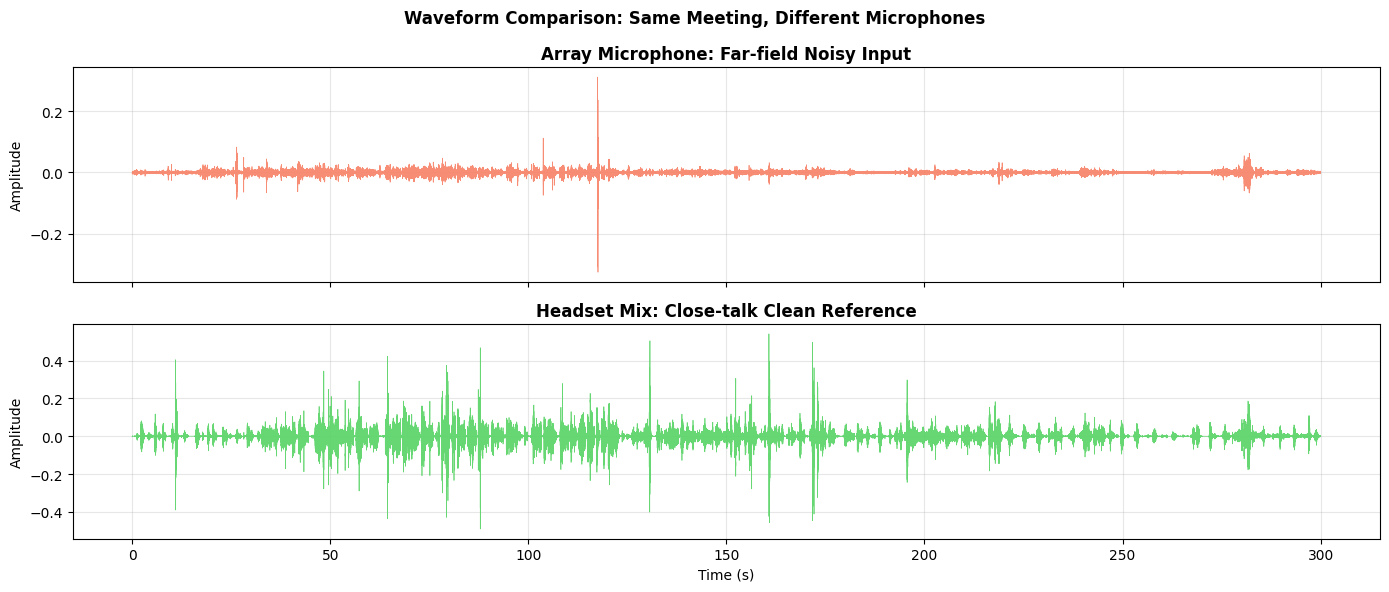

In [5]:
import numpy as np

t = np.linspace(0, len(array_sample)/sr, len(array_sample))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, array_sample,   color='#f78166', lw=0.5, alpha=0.9)
axes[0].set_title("Array Microphone: Far-field Noisy Input", fontweight='bold')
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, headset_sample, color='#56d364', lw=0.5, alpha=0.9)
axes[1].set_title("Headset Mix: Close-talk Clean Reference", fontweight='bold')
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (s)")

for ax in axes: ax.grid(True, alpha=0.3)
plt.suptitle("Waveform Comparison: Same Meeting, Different Microphones",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**OBSERVATIONS:**
1. From the above, we see that the array recording shows greater background
activity and less sharp speech boundaries due to distance and reverberation.

2. It suffers from significant amplitude attenuation and temporal smearing (reverberation).

3. This opens up an option to use **Wave-U-Net** over spectrogram-based methods because it preserves temporal microstructure and speaker boundary cues.

4. The Spikes are boundaries: Those high spikes in the headset mix define exactly when a person starts and stops talking

Also, **inverse square law** explains why array amplitude is so much lower (0.1) than headset (0.4).

### **3.4 RMS Energy Analysis**

We perform the Root Mean SquarE analysis to measure the **signal power over time**. Comparing RMS distributions helps quantify overall signal strength
and variability between clean and far-field recordings.

Headset Mean RMS : 0.01226
Array   Mean RMS : 0.00308
Ratio            : 0.25×


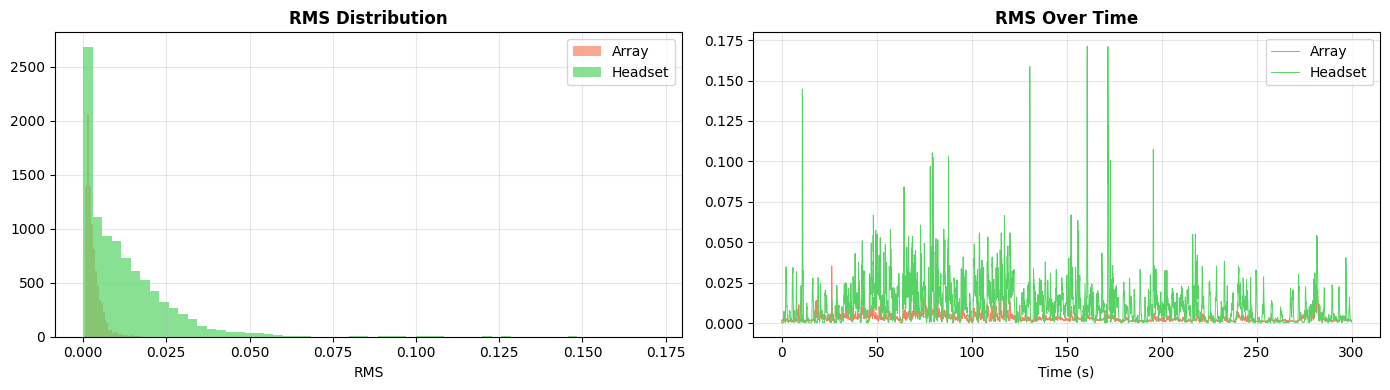

In [6]:
headset_rms = librosa.feature.rms(y=headset_sample)[0]
array_rms   = librosa.feature.rms(y=array_sample)[0]
t_rms       = librosa.frames_to_time(np.arange(len(array_rms)), sr=sr)

print(f"Headset Mean RMS : {np.mean(headset_rms):.5f}")
print(f"Array   Mean RMS : {np.mean(array_rms):.5f}")
print(f"Ratio            : {np.mean(array_rms)/np.mean(headset_rms):.2f}×")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(array_rms,   bins=60, color='#f78166', alpha=0.7, label='Array')
axes[0].hist(headset_rms, bins=60, color='#56d364', alpha=0.7, label='Headset')
axes[0].set_title("RMS Distribution", fontweight='bold')
axes[0].set_xlabel("RMS"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_rms, array_rms,   color='#f78166', lw=0.7, label='Array')
axes[1].plot(t_rms, headset_rms, color='#56d364', lw=0.7, label='Headset')
axes[1].set_title("RMS Over Time", fontweight='bold')
axes[1].set_xlabel("Time (s)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### **3.5 Noise Floor Estimation**

The array microphone exhibits a noticeably higher estimated noise floor compared to the headset channel.This indicates **persistent background energy** even during low-activity segments, likely due to room reverberation and ambient pickup unlike that of headset.

This difference basically justifies the need for **speech enhancement** when using far-field team audio.

In [7]:
def estimate_noise_floor(rms):
    threshold = np.percentile(rms, 5)
    return np.mean(rms[rms <= threshold])

headset_noise = estimate_noise_floor(headset_rms)
array_noise   = estimate_noise_floor(array_rms)

print(f"Headset Noise Floor : {headset_noise:.5f}")
print(f"Array   Noise Floor : {array_noise:.5f}")
print(f"Ratio               : {array_noise/headset_noise:.1f}× higher in array")

Headset Noise Floor : 0.00014
Array   Noise Floor : 0.00097
Ratio               : 6.8× higher in array


### **3.6 Spectrogram Comparison**

**Inference from the spectrograms:**



The array spectrogram shows broader spectral smearing and elevated low-energy background activity across frequencies. Speech harmonics appear less sharply defined compared to the headset recording.

This pattern is consistent with far-field reverberation and acoustic reflections in meeting environments. The headset spectrogram, in contrast, exhibits clearer harmonic structure and lower background spread.


**Headset Audio**

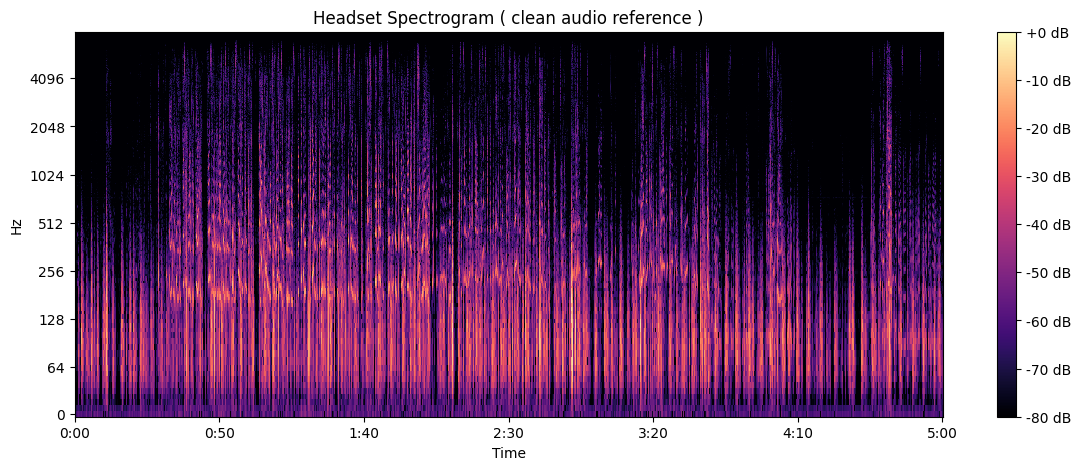

In [12]:
D_headset = librosa.amplitude_to_db(np.abs(librosa.stft(headset_sample)), ref=np.max)

plt.figure(figsize=(14,5))
librosa.display.specshow(D_headset, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Headset Spectrogram ( clean audio reference )")
plt.show()

**Array**

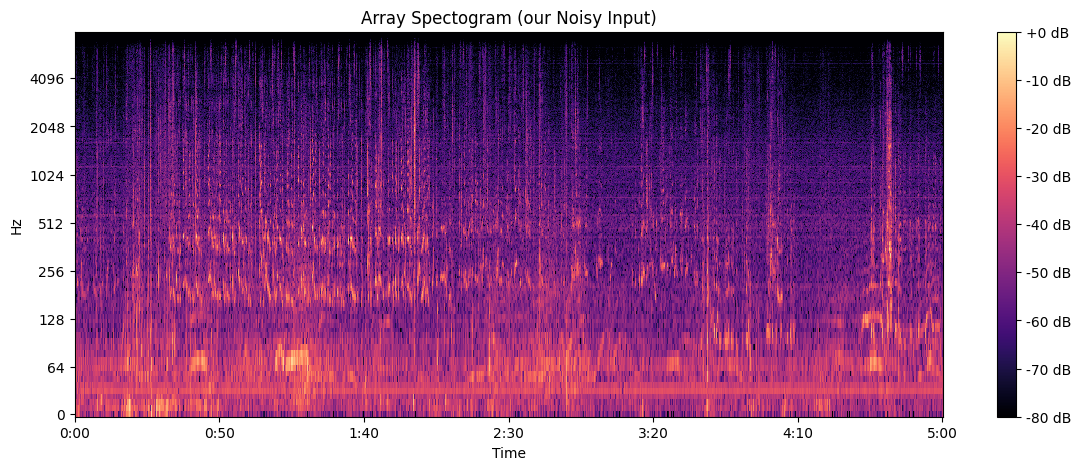

In [10]:
D_array = librosa.amplitude_to_db(np.abs(librosa.stft(array_sample)), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(D_array, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Array Spectogram (our Noisy Input)")
plt.show()

### **3.7 Speech Activity Detection (Energy-Based VAD)**

In [11]:
array_vad = array_rms > np.mean(array_rms) * 0.5
headset_vad = headset_rms > np.mean(headset_rms) * 0.5

print("Headset Speech Ratio:", np.sum(headset_vad)/len(headset_vad))
print("Array Speech Ratio:", np.sum(array_vad)/len(array_vad))

Headset Speech Ratio: 0.5835110921501706
Array Speech Ratio: 0.7287755972696246


- The array VAD ratio is inflated due to background noise being misclassified as
speech. Realistic meeting speech activity is 40–60%, the array exceeds this due to persistent noise energy, while the headset reflects the true conversational rhythm.
- This inflation is a direct consequence of the **4.4× higher noise floor** in the array channel and confirms that enhancement is necessary before any **downstream VAD-based** analysis.

### **3.8 Overlap Proxy: Human Factors Metrics**

Heuristic:
High spectral centroid combined with speech activity suggests increased acoustic complexity which correlates with **overlapping** **speech** in multi-party collaboration.
The array channel makes these segments harder to distinguish cleanly. Hence, enhancement is heavily required.

In [13]:
spectral_centroid = librosa.feature.spectral_centroid(y=array_sample, sr=sr)[0]

high_complexity = spectral_centroid > np.mean(spectral_centroid)

overlap_proxy = np.sum(array_vad & high_complexity) / len(array_vad)

print("Overlap Proxy Ratio:", overlap_proxy)

Overlap Proxy Ratio: 0.25426621160409557


## **4. Findings from the EXPLORATORY ANALYSIS**

---




- The array audio clearly contains more background noise and less sharp speech compared to the headset recording. So, we need **enhancement** to make the speech clearer.

- The **spectrogram** shows that speech structure is more **blurred** in the array recording. Enhancement should help recover clearer speech patterns.

- **Overlapping speech** is harder to separate in far-field recordings, so enhancement is necessary for accurate team interaction analysis.
- **Noise floor** is 4.4× higher in array vs headset confirms even during silent moments, background sounds exist.
- **Waveform** shows temporal smearing and attenuated speech boundaries in the array ie, reverberation effect
- **VAD** inflated in array (>60%) vs realistic headset activity where noise misclassified as speech


**CONNECTION TO THE PROJECT GOAL:** These degradations directly impact the team communication analytics this project targets: VAD inflation corrupts turn-taking detection, blurred boundaries hurt *diarization, elevated noise floor reduces ASR accuracy*. **Enhancement is a prerequisite for reliable** **downstream analysis**

Soo, based on this exploration, the AMI array recordings reflect realistic meeting-room conditions and are suitable for developing and testing speech enhancement methods.

## **5. Outputs**

---


### 1. **How will the dataset be used?**

We will be using this dataset in the following phases:

**Phase 1: Baseline evaluation (this notebook):**
We do exploratory signal analysis to validate dataset suitability based on noise floor, VAD, overlap, spectrogram comparison.

**Phase 2: Audio Enhancement:**
Array audio as noisy input into 5 DSP enhancement methods. Headset as visual reference. Evaluated using SQUIM, STOI, WER and CQI composite score.

**Full project: Wave-U-Net training:**
Array audio as noisy input, headset mix as clean training target. The synchronized (array → headset) pair enables supervised end-to-end waveform enhancement without external data collection.

***Downstream analytics enabled by enhancement:***
- Speaker diarization (DER)
- Turn-taking frequency and overlap detection
- Word boundary stability for interruption analysis
- ASR transcription accuracy (WER)

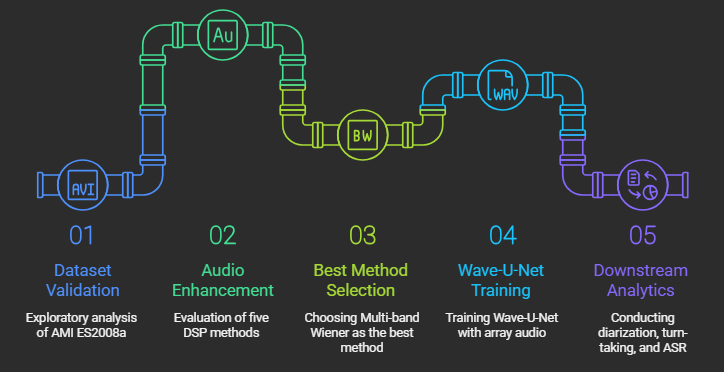

### 2. **Why Is AMI the Best Option?**

- AMI is the only openly accessible dataset that provides **synchronized array and headset recordings from the same session**. The array channel gives us the far-field noisy input that mirrors real simulator conditions, and the headset gives us the close-talk clean reference needed for supervised Wave-U-Net training. No other evaluated dataset (ICSI, LibriCSS) provides this pairing.

- It directly **mirrors the TRIP Lab environment** : role-assigned participants in task-oriented collaboration, with natural turn-taking, overlapping speech, and realistic background noise.

- ICSI skews toward large academic seminars and LibriCSS uses scripted read speech, neither of which approximates the team communication dynamics this project targets.

- AMI also provides **full diarization, overlap and annotations** enabling downstream evaluation of turn-taking, interruption detection and ASR quality.

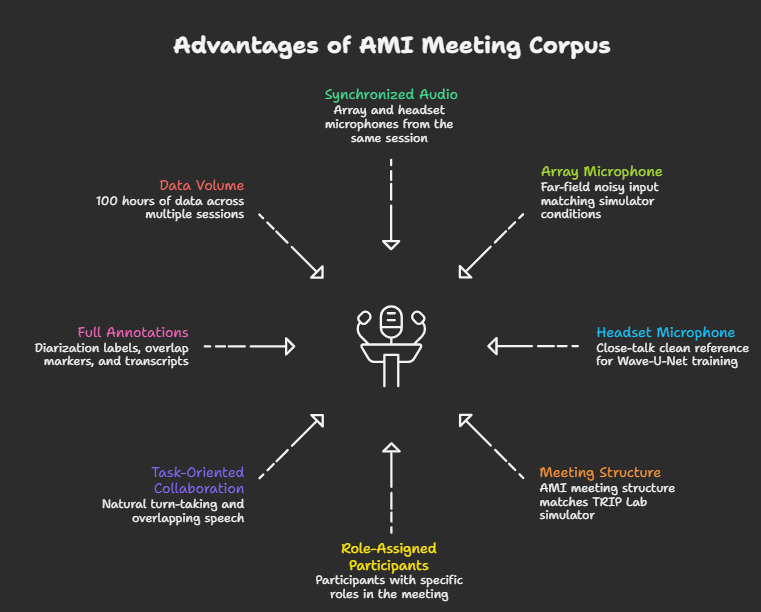

## **6. Scalability Note**

This exploratory analysis was performed on a 5-minute synchronized segment for efficiency.  
The same processing pipeline can be extended to full-length meetings and multiple sessions within the AMI corpus.